# IT2011 AI & ML - Group Model Comparison
Aggregates the six exported `results/<STUDENT_ID>_metrics.json` files. **Run the six individual notebooks first.**

In [6]:
# ===== Cell 1: Load all exported JSON metrics =====
import os, json, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RESULTS_DIR = "results"
TEAM_IDS = ["IT25100788", "IT25102855", "IT25101499", "IT25100185", "IT25103271", "IT25102298"]

all_metrics, missing = {}, []
for sid in TEAM_IDS:
    path = f"{RESULTS_DIR}/{sid}_metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[sid] = json.load(f)
    else:
        missing.append(sid)
if missing:
    print("WARNING - missing metrics files for:", missing)
print(f"Loaded {len(all_metrics)}/6 models from {RESULTS_DIR}/")


Loaded 6/6 models from results/


In [7]:
# ===== Cell 2: Master benchmark table =====
cols = ["accuracy", "precision", "recall", "weighted_f1", "macro_f1", "roc_auc"]
rows = []
for sid, m in all_metrics.items():
    rows.append({"Model": m["model"], "Student": sid, "Feature set": m["feature_set"],
                 **{c: m[c] for c in cols}, "CV weighted F1": m["cv_weighted_f1"]})
bench = (pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True))
bench.index += 1
bench.rename(columns={"accuracy":"Accuracy","precision":"Precision","recall":"Recall",
                      "weighted_f1":"Weighted F1","macro_f1":"Macro F1","roc_auc":"ROC-AUC"}, inplace=True)
pd.set_option("display.width", 200)
print(bench.round(4).to_string())
bench.to_csv(f"{RESULTS_DIR}/group_benchmark_table.csv")
bench.round(4)


                          Model     Student                 Feature set  Accuracy  Precision  Recall  Weighted F1  Macro F1  ROC-AUC  CV weighted F1
1                 Random Forest  IT25100185  Standardized (12 features)    0.8846     0.7548  0.6133       0.8799    0.8032   0.9104          0.8769
2           K-Nearest Neighbors  IT25101499  Standardized (12 features)    0.8715     0.7014  0.6055       0.8679    0.7856   0.8725          0.8678
3  Support Vector Machine (SVC)  IT25103271  Standardized (12 features)    0.8415     0.6524  0.4180       0.8275    0.7075   0.8497          0.8289
4  Multi-Layer Perceptron (MLP)  IT25102298          PCA (6 components)    0.8238     0.5659  0.4531       0.8162    0.6981   0.8430          0.8249
5           Logistic Regression  IT25100788  Standardized (12 features)    0.8223     0.6147  0.2617       0.7924    0.6319   0.8050          0.7900
6                 Decision Tree  IT25102855  Standardized (12 features)    0.8485     0.6122  0.6289      

,Model,Student,Feature set,Accuracy,Precision,Recall,Weighted F1,Macro F1,ROC-AUC,CV weighted F1
1,Random Forest,IT25100185,Standardized (12 features),0.8846,0.7548,0.6133,0.8799,0.8032,0.9104,0.8769
2,K-Nearest Neighbors,IT25101499,Standardized (12 features),0.8715,0.7014,0.6055,0.8679,0.7856,0.8725,0.8678
3,Support Vector Machine (SVC),IT25103271,Standardized (12 features),0.8415,0.6524,0.4180,0.8275,0.7075,0.8497,0.8289
4,Multi-Layer Perceptron (MLP),IT25102298,PCA (6 components),0.8238,0.5659,0.4531,0.8162,0.6981,0.8430,0.8249
5,Logistic Regression,IT25100788,Standardized (12 features),0.8223,0.6147,0.2617,0.7924,0.6319,0.8050,0.7900
6,Decision Tree,IT25102855,Standardized (12 features),0.8485,0.6122,0.6289,0.8492,0.7629,0.7656,0.8434


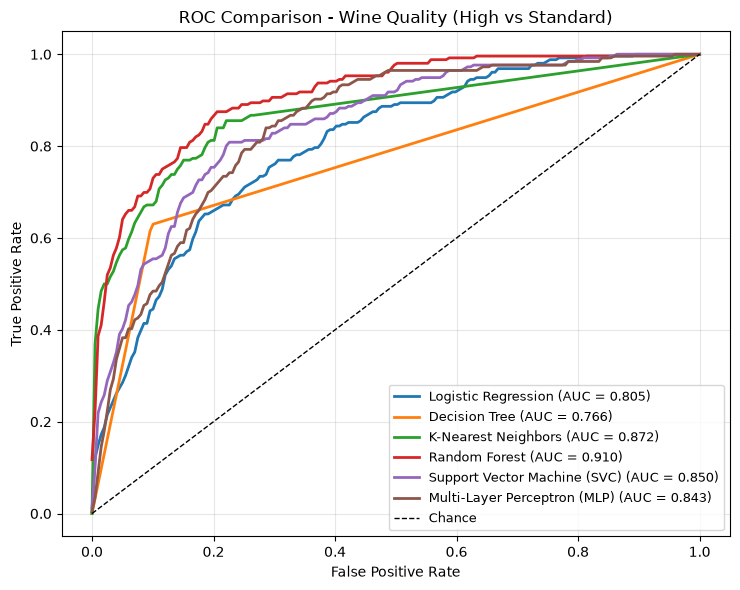

In [8]:
# ===== Cell 3: Overlaid ROC curves =====
plt.figure(figsize=(7.5, 6))
palette = sns.color_palette("tab10", len(all_metrics))
for color, (sid, m) in zip(palette, all_metrics.items()):
    plt.plot(m["roc_curve"]["fpr"], m["roc_curve"]["tpr"], lw=2, color=color,
             label=f"{m['model']} (AUC = {m['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Comparison - Wine Quality (High vs Standard)")
plt.legend(loc="lower right", fontsize=9); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/group_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


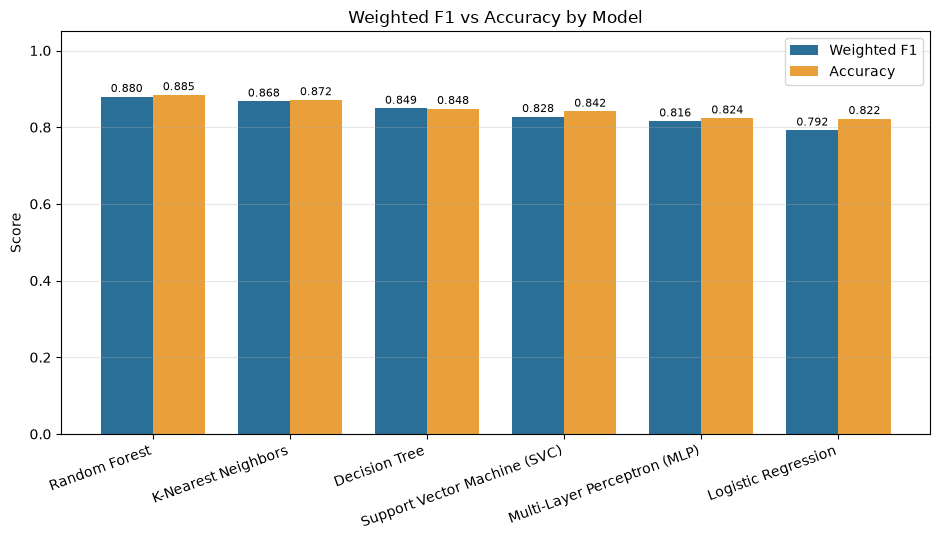

In [9]:
# ===== Cell 4: Grouped bar chart - Weighted F1 vs Accuracy =====
plot_df = bench.sort_values("Weighted F1", ascending=False)
x = np.arange(len(plot_df)); w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 5.5))
b1 = ax.bar(x - w/2, plot_df["Weighted F1"], w, label="Weighted F1", color="#2a6f97")
b2 = ax.bar(x + w/2, plot_df["Accuracy"],    w, label="Accuracy",    color="#e9a03b")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score"); ax.set_title("Weighted F1 vs Accuracy by Model")
ax.legend(); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/group_metrics_barchart.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# ===== Cell 5: Analytical summary (generated from the actual results) =====
best  = bench.iloc[0]; worst = bench.iloc[-1]
by_f1 = bench.sort_values("Weighted F1", ascending=False)["Model"].tolist()
tn, fp, fn, tp = np.array(next(iter(all_metrics.values()))["confusion_matrix"]).ravel()
majority_acc = (tn + fp) / (tn + fp + fn + tp)

def get(name_part, col):
    r = bench[bench["Model"].str.contains(name_part, regex=False)]
    return float(r[col].iloc[0]) if len(r) else float("nan")

print("=" * 70); print("ANALYTICAL SUMMARY"); print("=" * 70)
print(f"\n1. RANKING\n   By ROC-AUC:     {' > '.join(bench['Model'])}")
print(f"   By Weighted F1: {' > '.join(by_f1)}")
print(f"   Best overall: {best['Model']} (AUC {best['ROC-AUC']:.3f}, weighted F1 {best['Weighted F1']:.3f}); "
      f"weakest: {worst['Model']} (AUC {worst['ROC-AUC']:.3f}).")

rf_auc, lr_auc = get("Random Forest", "ROC-AUC"), get("Logistic", "ROC-AUC")
dt_auc = get("Decision Tree", "ROC-AUC")
print("\n2. BIAS-VARIANCE TRADE-OFF")
print(f"   Linear baseline (Logistic Regression) AUC = {lr_auc:.3f} vs Random Forest AUC = {rf_auc:.3f} "
      f"(gap {rf_auc - lr_auc:+.3f}).")
print("   Logistic Regression is a high-bias / low-variance model: one linear boundary cannot capture the")
print("   non-linear interactions between alcohol, acidity and sulphates. Ensembles such as Random Forest")
print("   reduce the variance of deep trees by averaging decorrelated trees while keeping low bias.")
print(f"   A single Decision Tree (AUC {dt_auc:.3f}) shows the high-variance end; averaging it into a forest")
print(f"   changes AUC by {rf_auc - dt_auc:+.3f}. Flexible, kernel/neural models (SVC, MLP) sit in between and rely")
print("   on regularisation (C/gamma, alpha/early stopping) to control variance; KNN's k plays that role.")

print("\n3. IMPACT OF CLASS IMBALANCE")
print(f"   A trivial 'always Standard' classifier would reach about {majority_acc:.1%} accuracy with 0% recall.")
print(f"   Accuracy range across models: {bench['Accuracy'].min():.3f}-{bench['Accuracy'].max():.3f}, but recall on the")
print(f"   high-quality class ranges only {bench['Recall'].min():.3f}-{bench['Recall'].max():.3f} and macro F1 "
      f"{bench['Macro F1'].min():.3f}-{bench['Macro F1'].max():.3f}.")
print("   Accuracy therefore overstates performance and compresses differences between models; F1 and ROC-AUC")
print("   are better discriminators. Models with class_weight / balanced options trade precision for recall.")
print("   Future work: threshold tuning, SMOTE/class weights inside CV, and precision-recall analysis.")


ANALYTICAL SUMMARY

1. RANKING
   By ROC-AUC:     Random Forest > K-Nearest Neighbors > Support Vector Machine (SVC) > Multi-Layer Perceptron (MLP) > Logistic Regression > Decision Tree
   By Weighted F1: Random Forest > K-Nearest Neighbors > Decision Tree > Support Vector Machine (SVC) > Multi-Layer Perceptron (MLP) > Logistic Regression
   Best overall: Random Forest (AUC 0.910, weighted F1 0.880); weakest: Decision Tree (AUC 0.766).

2. BIAS-VARIANCE TRADE-OFF
   Linear baseline (Logistic Regression) AUC = 0.805 vs Random Forest AUC = 0.910 (gap +0.105).
   Logistic Regression is a high-bias / low-variance model: one linear boundary cannot capture the
   non-linear interactions between alcohol, acidity and sulphates. Ensembles such as Random Forest
   reduce the variance of deep trees by averaging decorrelated trees while keeping low bias.
   A single Decision Tree (AUC 0.766) shows the high-variance end; averaging it into a forest
   changes AUC by +0.145. Flexible, kernel/neural m